<a href="https://colab.research.google.com/github/subod4/ADdetection/blob/main/alzheimer_audio_cnn2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Alzheimer's Disease Diagnosis - Complete Improved Pipeline

Based on your original code but with ALL critical improvements:
1. Segmentation usage (extracts only PAR segments)
2. Data augmentation (multiplies dataset)
3. Proper train/val/test split
4. Standardized segment lengths
5. K-fold cross-validation option
6. Test predictions for submission

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from collections import Counter
import pickle
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
!nvidia-smi

print("="*80)
print("ALZHEIMER'S DISEASE DIAGNOSIS - COMPLETE IMPROVED PIPELINE")
print("="*80)

Wed Jan 21 18:19:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Configuration

In [13]:
CONFIG = {
    'sr': 16000,                    # Sample rate
    'segment_duration': 3.0,        # Standardize segments to 3 seconds
    'min_segment_duration': 1.0,    # Minimum segment length to keep
    'n_mels': 128,                  # Number of mel bands
    'fmax': 8000,                   # Maximum frequency
    'use_augmentation': True,       # Enable data augmentation
    'use_kfold': True,              # Use K-fold cross-validation
    'n_folds': 5,                   # Number of folds for cross-validation
    'epochs': 50,                   # Maximum epochs
    'batch_size': 32,               # Batch size
    'learning_rate': 0.0005,        # Learning rate
    'test_folder': '/content/test-dist/audio',
    'test_seg_folder': '/content/test-dist/segmentation'  # Test segmentation folder
}

## 1. Data Loading with Segmentation (CRITICAL IMPROVEMENT!)

This is THE KEY improvement - we extract only patient speech (PAR segments)!

In [14]:
def augment_audio(y, sr=16000):
    """
    Apply data augmentation to increase dataset diversity.
    Returns list of augmented versions.
    """
    augmented = [y]  # Original

    # Time stretching (90-110% speed)
    if np.random.rand() > 0.5:
        rate = np.random.uniform(0.90, 1.10)
        y_stretch = librosa.effects.time_stretch(y, rate=rate)
        if len(y_stretch) < len(y):
            y_stretch = np.pad(y_stretch, (0, len(y) - len(y_stretch)))
        else:
            y_stretch = y_stretch[:len(y)]
        augmented.append(y_stretch)

    # Pitch shifting (-2 to +2 semitones)
    if np.random.rand() > 0.5:
        n_steps = np.random.randint(-2, 3)
        if n_steps != 0:
            y_pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)
            augmented.append(y_pitch)

    # Add subtle noise
    if np.random.rand() > 0.5:
        noise = np.random.normal(0, 0.003, y.shape)
        y_noise = y + noise
        y_noise = librosa.util.normalize(y_noise)
        augmented.append(y_noise)

    return augmented

def load_segmented_audio(audio_file, seg_file, label, sr=16000,
                        speaker='PAR', min_duration=1.0, augment=False):
    """
    Load only participant (PAR) segments from audio file.
    This is THE KEY improvement - we extract only patient speech!
    """
    segments = []

    try:
        # Read segmentation file
        seg_df = pd.read_csv(seg_file)

        # Load full audio
        y_full, _ = librosa.load(audio_file, sr=sr)

        # Extract only PAR (participant) segments
        par_segments = seg_df[seg_df['speaker'] == speaker]

        for _, row in par_segments.iterrows():
            # Convert milliseconds to samples
            begin_sample = int(row['begin'] * sr / 1000)
            end_sample = int(row['end'] * sr / 1000)

            segment = y_full[begin_sample:end_sample]

            # Only keep segments longer than min_duration
            if len(segment) > sr * min_duration:
                segment = librosa.util.normalize(segment)

                # Apply augmentation if enabled
                if augment:
                    aug_segments = augment_audio(segment, sr)
                    for aug_seg in aug_segments:
                        segments.append((aug_seg, label))
                else:
                    segments.append((segment, label))

    except Exception as e:
        print(f"  Error processing {os.path.basename(audio_file)}: {e}")

    return segments

def load_all_segmented_audio(audio_folder, seg_folder, label, augment=False):
    """Load all segmented audio from a folder"""
    all_segments = []
    files_processed = 0

    audio_files = sorted([f for f in os.listdir(audio_folder) if f.endswith('.wav')])

    for filename in audio_files:
        audio_path = os.path.join(audio_folder, filename)
        seg_path = os.path.join(seg_folder, filename.replace('.wav', '.csv'))

        if os.path.exists(seg_path):
            segments = load_segmented_audio(
                audio_path, seg_path, label,
                CONFIG['sr'], augment=augment
            )
            all_segments.extend(segments)
            files_processed += 1

            if files_processed % 20 == 0:
                print(f"  Processed {files_processed}/{len(audio_files)} files, "
                      f"{len(all_segments)} segments extracted")
        else:
            print(f"  Warning: No segmentation for {filename}")

    print(f"  ✓ Completed: {files_processed} files → {len(all_segments)} segments")
    return all_segments

In [15]:
# Load training data WITH segmentation
print("\n1️⃣  LOADING TRAINING DATA WITH SEGMENTATION")
print("-" * 80)

ad_folder = '/content/train/audio/ad'
cn_folder = '/content/train/audio/cn'
ad_seg_folder = '/content/train/segmentation/ad'
cn_seg_folder = '/content/train/segmentation/cn'

print("Loading AD (Alzheimer's) segments...")
ad_segments = load_all_segmented_audio(
    ad_folder, ad_seg_folder, 'AD',
    augment=CONFIG['use_augmentation']
)

print("\nLoading CN (Control) segments...")
cn_segments = load_all_segmented_audio(
    cn_folder, cn_seg_folder, 'CN',
    augment=CONFIG['use_augmentation']
)

all_segments = ad_segments + cn_segments
print(f"\n📊 TOTAL SEGMENTS: {len(all_segments)}")
print(f"   AD: {len(ad_segments)} | CN: {len(cn_segments)}")
print(f"   Augmentation: {'ENABLED' if CONFIG['use_augmentation'] else 'DISABLED'}")


1️⃣  LOADING TRAINING DATA WITH SEGMENTATION
--------------------------------------------------------------------------------
Loading AD (Alzheimer's) segments...
  Processed 20/87 files, 847 segments extracted
  Processed 40/87 files, 1384 segments extracted
  Processed 60/87 files, 1883 segments extracted
  Processed 80/87 files, 2514 segments extracted
  ✓ Completed: 87 files → 2702 segments

Loading CN (Control) segments...
  Processed 20/79 files, 500 segments extracted
  Processed 40/79 files, 1083 segments extracted
  Processed 60/79 files, 1770 segments extracted
  ✓ Completed: 79 files → 2461 segments

📊 TOTAL SEGMENTS: 5163
   AD: 2702 | CN: 2461
   Augmentation: ENABLED


## 2. Standardize Segment Lengths (Fix Variable Length Issue)

In [16]:
print("\n2️⃣  STANDARDIZING SEGMENT LENGTHS")
print("-" * 80)

def standardize_segment_length(segment, target_length):
    """Pad or trim to consistent length"""
    if len(segment) < target_length:
        return np.pad(segment, (0, target_length - len(segment)), mode='constant')
    else:
        return segment[:target_length]

TARGET_LENGTH = int(CONFIG['sr'] * CONFIG['segment_duration'])

audio_data = []
labels = []

for segment, label in all_segments:
    standardized = standardize_segment_length(segment, TARGET_LENGTH)
    audio_data.append(standardized)
    labels.append(label)

print(f"✓ Standardized {len(audio_data)} segments to {CONFIG['segment_duration']}s")
print(f"  Sample length: {TARGET_LENGTH} samples ({TARGET_LENGTH/CONFIG['sr']:.1f}s)")


2️⃣  STANDARDIZING SEGMENT LENGTHS
--------------------------------------------------------------------------------
✓ Standardized 5163 segments to 3.0s
  Sample length: 48000 samples (3.0s)


## 3. Extract Spectrograms with Consistent Shape


3️⃣  EXTRACTING MEL SPECTROGRAMS
--------------------------------------------------------------------------------
✓ Extracted 5163 spectrograms
  Shape: (128, 94) (n_mels × time_frames)
  All shapes consistent: True


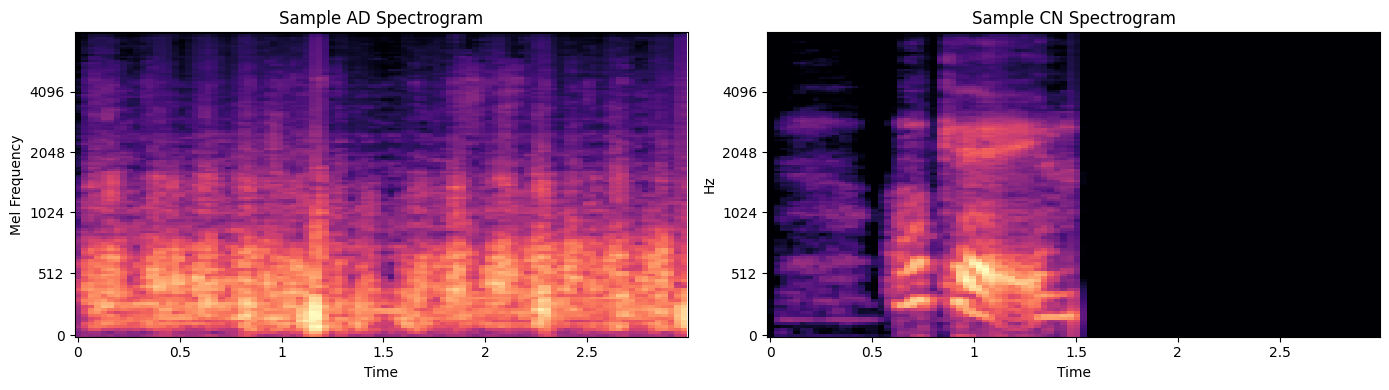

In [17]:
print("\n3️⃣  EXTRACTING MEL SPECTROGRAMS")
print("-" * 80)

def audio_to_melspectrogram(audio, sr=16000, n_mels=128, fmax=8000):
    """Extract Mel spectrogram in dB scale"""
    S = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels, fmax=fmax)
    S_dB = librosa.power_to_db(S, ref=np.max)
    return S_dB

spectrograms = [audio_to_melspectrogram(
    audio, CONFIG['sr'], CONFIG['n_mels'], CONFIG['fmax']
) for audio in audio_data]

print(f"✓ Extracted {len(spectrograms)} spectrograms")
print(f"  Shape: {spectrograms[0].shape} (n_mels × time_frames)")
print(f"  All shapes consistent: {all(s.shape == spectrograms[0].shape for s in spectrograms)}")

# Visualize sample spectrograms
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ad_idx = labels.index('AD')
cn_idx = labels.index('CN')

librosa.display.specshow(spectrograms[ad_idx], sr=CONFIG['sr'],
                        x_axis='time', y_axis='mel', fmax=CONFIG['fmax'], ax=axes[0])
axes[0].set_title('Sample AD Spectrogram', fontsize=12)
axes[0].set_ylabel('Mel Frequency')

librosa.display.specshow(spectrograms[cn_idx], sr=CONFIG['sr'],
                        x_axis='time', y_axis='mel', fmax=CONFIG['fmax'], ax=axes[1])
axes[1].set_title('Sample CN Spectrogram', fontsize=12)

plt.tight_layout()
plt.show()

## 4. Prepare Data with Proper Split

In [18]:
print("\n4️⃣  PREPARING DATA SPLIT")
print("-" * 80)

# Encode labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# Check class distribution
unique, counts = np.unique(labels_encoded, return_counts=True)
print("Class distribution:")
for cls, count in zip(le.classes_, counts):
    print(f"  {cls}: {count} segments ({count/len(labels_encoded)*100:.1f}%)")

# Prepare arrays
X = np.array(spectrograms)[..., np.newaxis]  # Add channel dimension
y = labels_encoded

# Split: 80% train, 20% test (we'll use validation split during training)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nData split:")
print(f"  Training: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Test: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"  Input shape: {X_train.shape[1:]}")


4️⃣  PREPARING DATA SPLIT
--------------------------------------------------------------------------------
Class distribution:
  AD: 2702 segments (52.3%)
  CN: 2461 segments (47.7%)

Data split:
  Training: 4130 samples (80%)
  Test: 1033 samples (20%)
  Input shape: (128, 94, 1)


## 5. Build Model with Regularization

In [19]:
print("\n5️⃣  BUILDING CNN MODEL")
print("-" * 80)

def build_cnn_model(input_shape, num_classes=2):
    """
    CNN optimized for small datasets with heavy regularization
    """
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                     input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Dense layers
        layers.Flatten(),
        layers.Dense(128, activation='relu',
                    kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

model = build_cnn_model(input_shape=X_train.shape[1:])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG['learning_rate']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"\n📊 Trainable parameters: {trainable_params:,}")


5️⃣  BUILDING CNN MODEL
--------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 94, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 94, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 47, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 23, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 22528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,883,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,986,178 (11.39 MB)

 Trainable params: 2,985,474 (11.39 MB)

 Non-trainable params: 704 (2.75 KB)


📊 Trainable parameters: 2,985,474


## 6. Train Model (with K-Fold Option)

In [20]:
print("\n6️⃣  TRAINING MODEL")
print("-" * 80)

if CONFIG['use_kfold']:
    print(f"Using {CONFIG['n_folds']}-Fold Cross-Validation")
    print("=" * 80)

    kfold = StratifiedKFold(n_splits=CONFIG['n_folds'], shuffle=True, random_state=42)
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train), 1):
        print(f"\nFOLD {fold}/{CONFIG['n_folds']}")
        print("-" * 40)

        # Build fresh model for each fold
        fold_model = build_cnn_model(input_shape=X_train.shape[1:])
        fold_model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG['learning_rate']),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        # Callbacks
        early_stop = EarlyStopping(monitor='val_loss', patience=10,
                                  restore_best_weights=True, verbose=0)

        # Train
        fold_history = fold_model.fit(
            X_train[train_idx], y_train[train_idx],
            validation_data=(X_train[val_idx], y_train[val_idx]),
            epochs=CONFIG['epochs'],
            batch_size=CONFIG['batch_size'],
            callbacks=[early_stop],
            verbose=0
        )

        # Evaluate
        val_loss, val_acc = fold_model.evaluate(X_train[val_idx], y_train[val_idx], verbose=0)
        fold_scores.append(val_acc)
        print(f"Validation Accuracy: {val_acc:.4f}")

    print("\n" + "=" * 80)
    print("CROSS-VALIDATION RESULTS:")
    print(f"  Mean Accuracy: {np.mean(fold_scores):.4f} (±{np.std(fold_scores):.4f})")
    print(f"  Range: [{np.min(fold_scores):.4f}, {np.max(fold_scores):.4f}]")
    print("=" * 80)

    # Train final model on ALL training data
    print("\nTraining final model on full training set...")

    model = build_cnn_model(input_shape=X_train.shape[1:])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG['learning_rate']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(monitor='val_loss', patience=15,
                              restore_best_weights=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                 patience=7, min_lr=1e-7, verbose=1)

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=CONFIG['epochs'],
        batch_size=CONFIG['batch_size'],
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

else:
    # Simple training with validation split
    print("Training with validation split (20% of training data)...")

    early_stop = EarlyStopping(monitor='val_loss', patience=15,
                              restore_best_weights=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                 patience=7, min_lr=1e-7, verbose=1)

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=CONFIG['epochs'],
        batch_size=CONFIG['batch_size'],
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )


6️⃣  TRAINING MODEL
--------------------------------------------------------------------------------
Using 5-Fold Cross-Validation

FOLD 1/5
----------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation Accuracy: 0.7482

FOLD 2/5
----------------------------------------
Validation Accuracy: 0.7930

FOLD 3/5
----------------------------------------
Validation Accuracy: 0.7809

FOLD 4/5
----------------------------------------
Validation Accuracy: 0.7482

FOLD 5/5
----------------------------------------
Validation Accuracy: 0.7167

CROSS-VALIDATION RESULTS:
  Mean Accuracy: 0.7574 (±0.0270)
  Range: [0.7167, 0.7930]

Training final model on full training set...
Epoch 1/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 96ms/step - accuracy: 0.5141 - loss: 1.3692 - val_accuracy: 0.5048 - val_loss: 0.9934 - learning_rate: 5.0000e-04
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5532 - loss: 1.1142 - val_accuracy: 0.5944 - val_loss: 0.9710 - learning_rate: 5.0000e-04
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5552 - loss: 1.0658 - val_accuracy: 0.6077 - val_loss: 0.9538 - learning_rate: 5.0000e-04
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/ste

## 7. Evaluate on Held-Out Test Set


7️⃣  EVALUATION ON HELD-OUT TEST SET

🎯 Test Accuracy: 0.8683 (86.83%)

Classification Report:
              precision    recall  f1-score   support

          AD     0.8497    0.9094    0.8786       541
          CN     0.8921    0.8232    0.8562       492

    accuracy                         0.8683      1033
   macro avg     0.8709    0.8663    0.8674      1033
weighted avg     0.8699    0.8683    0.8679      1033



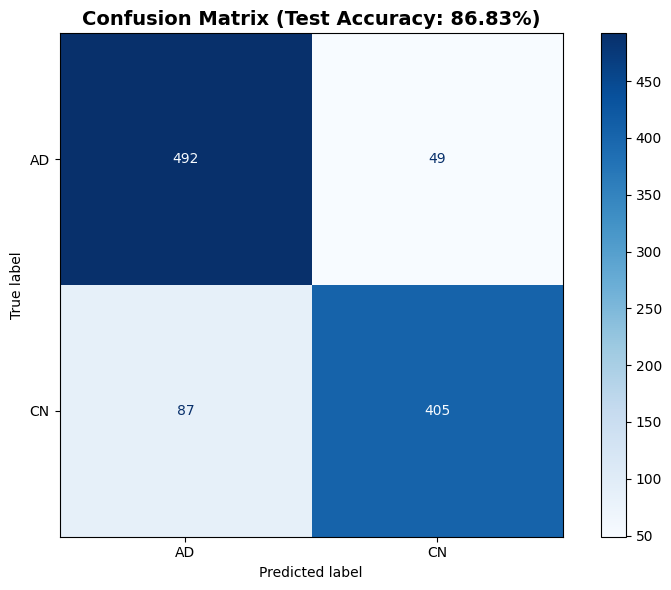


Per-Class Accuracy:
  AD: 0.9094 (541 samples)
  CN: 0.8232 (492 samples)


In [21]:
print("\n7️⃣  EVALUATION ON HELD-OUT TEST SET")
print("=" * 80)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
test_acc = accuracy_score(y_test, y_pred)

print(f"\n🎯 Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)
plt.title(f'Confusion Matrix (Test Accuracy: {test_acc:.2%})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Per-class performance
print("\nPer-Class Accuracy:")
for i, cls in enumerate(le.classes_):
    mask = y_test == i
    if mask.sum() > 0:
        class_acc = accuracy_score(y_test[mask], y_pred[mask])
        print(f"  {cls}: {class_acc:.4f} ({mask.sum()} samples)")

Advance visualization

In [22]:
print("\n📊 ADVANCED MODEL EVALUATION METRICS")
print("=" * 80)

from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             average_precision_score, roc_auc_score)
from sklearn.calibration import calibration_curve

# Get prediction probabilities for the test set
y_pred_proba_test = model.predict(X_test, verbose=0)

# For binary classification (AD vs CN)
# Assuming class 0 = AD, class 1 = CN (check with le.classes_)
print(f"Classes: {le.classes_}")
print(f"Class 0: {le.classes_[0]}, Class 1: {le.classes_[1]}")

# Get probabilities for the positive class (AD)
# We'll use AD as the positive class for clinical relevance
ad_class_idx = list(le.classes_).index('AD') if 'AD' in le.classes_ else 0
y_scores = y_pred_proba_test[:, ad_class_idx]  # Probability of AD class

# Create binary labels (1 for AD, 0 for CN)
y_true_binary = (y_test == ad_class_idx).astype(int)
y_pred_binary = (y_pred == ad_class_idx).astype(int)


📊 ADVANCED MODEL EVALUATION METRICS
Classes: ['AD' 'CN']
Class 0: AD, Class 1: CN


ROC Curve and AUC


📈 ROC CURVE AND AUC
--------------------------------------------------


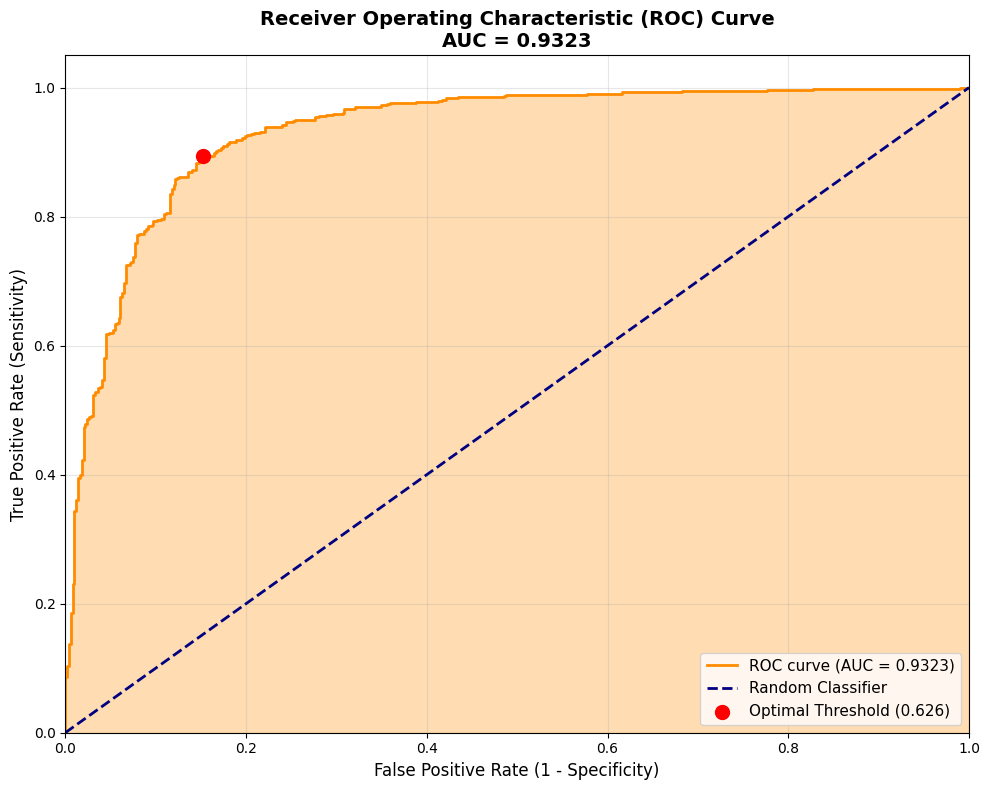

✓ AUC-ROC Score: 0.9323
✓ Optimal Threshold (Youden's J): 0.6259


In [23]:
# ROC Curve
print("\n📈 ROC CURVE AND AUC")
print("-" * 50)

fpr, tpr, thresholds_roc = roc_curve(y_true_binary, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.3, color='darkorange')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title(f'Receiver Operating Characteristic (ROC) Curve\nAUC = {roc_auc:.4f}', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)

# Add optimal threshold point (Youden's J statistic)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds_roc[optimal_idx]
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red', s=100,
            label=f'Optimal Threshold ({optimal_threshold:.3f})', zorder=5)
plt.legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.show()

print(f"✓ AUC-ROC Score: {roc_auc:.4f}")
print(f"✓ Optimal Threshold (Youden's J): {optimal_threshold:.4f}")

Precision-Recall(PR) curve


📉 PRECISION-RECALL CURVE
--------------------------------------------------


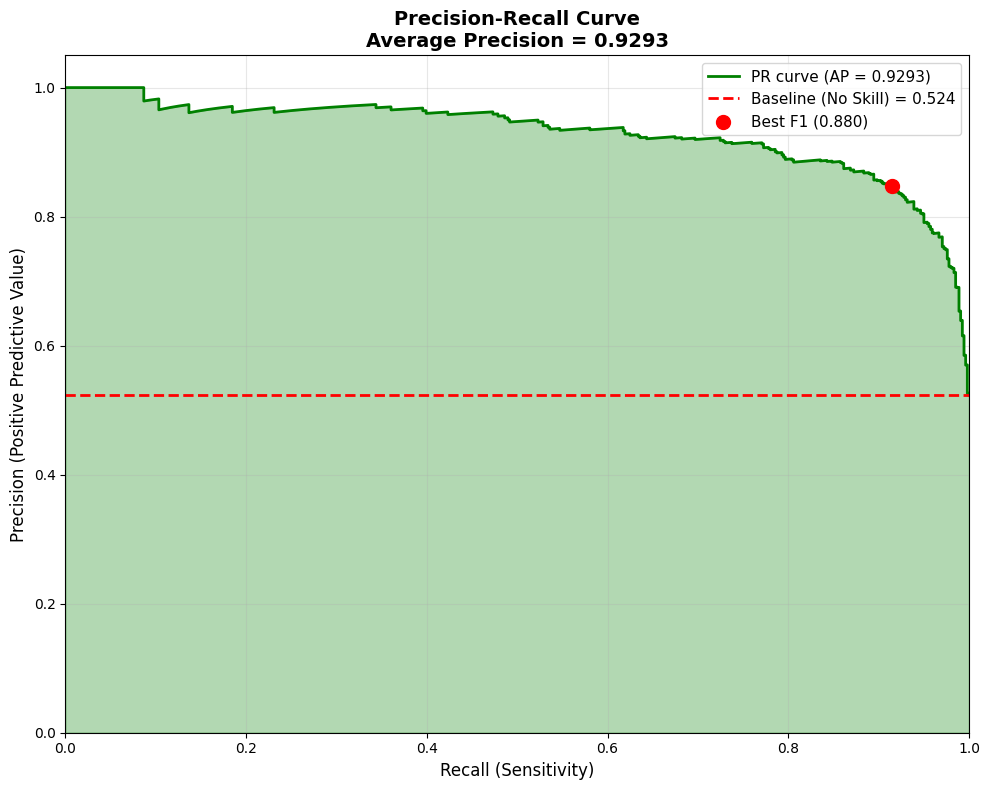

✓ Average Precision (AP) Score: 0.9293
✓ Best F1 Score: 0.8800


In [24]:
# Precision-Recall Curve
print("\n📉 PRECISION-RECALL CURVE")
print("-" * 50)

precision, recall, thresholds_pr = precision_recall_curve(y_true_binary, y_scores)
avg_precision = average_precision_score(y_true_binary, y_scores)

# Calculate baseline (proportion of positive class)
baseline = np.sum(y_true_binary) / len(y_true_binary)

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, color='green', lw=2, label=f'PR curve (AP = {avg_precision:.4f})')
plt.axhline(y=baseline, color='red', linestyle='--', lw=2, label=f'Baseline (No Skill) = {baseline:.3f}')
plt.fill_between(recall, precision, alpha=0.3, color='green')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (Sensitivity)', fontsize=12)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=12)
plt.title(f'Precision-Recall Curve\nAverage Precision = {avg_precision:.4f}', fontsize=14, fontweight='bold')
plt.legend(loc="upper right", fontsize=11)
plt.grid(True, alpha=0.3)

# Find threshold for best F1 score
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_f1_idx = np.argmax(f1_scores[:-1])  # Exclude last value (recall=0)
plt.scatter(recall[best_f1_idx], precision[best_f1_idx], marker='o', color='red', s=100,
            label=f'Best F1 ({f1_scores[best_f1_idx]:.3f})', zorder=5)
plt.legend(loc="upper right", fontsize=11)

plt.tight_layout()
plt.show()

print(f"✓ Average Precision (AP) Score: {avg_precision:.4f}")
print(f"✓ Best F1 Score: {f1_scores[best_f1_idx]:.4f}")

sensitivity and specificity analysis


🔬 SENSITIVITY / SPECIFICITY ANALYSIS
--------------------------------------------------

📊 Confusion Matrix Components:
   True Positives (TP):  492
   True Negatives (TN):  405
   False Positives (FP): 87
   False Negatives (FN): 49

📈 Performance Metrics (AD as positive class):
   Sensitivity (Recall/TPR):     0.9094 (90.94%)
   Specificity (TNR):            0.8232 (82.32%)
   Precision (PPV):              0.8497 (84.97%)
   Negative Predictive Value:    0.8921 (89.21%)
   F1 Score:                     0.8786
   Balanced Accuracy:            0.8663 (86.63%)


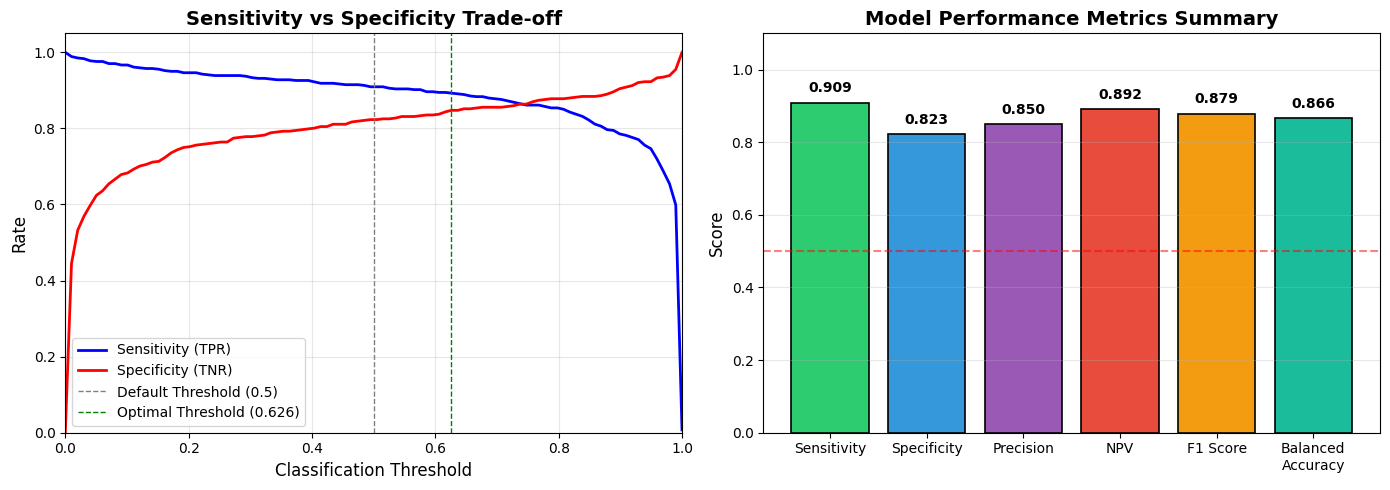

In [25]:
# Sensitivity and Specificity Analysis
print("\n🔬 SENSITIVITY / SPECIFICITY ANALYSIS")
print("-" * 50)

# Calculate confusion matrix components
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true_binary, y_pred_binary)
TN, FP, FN, TP = cm.ravel()

# Calculate metrics
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0  # True Positive Rate (Recall)
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0  # True Negative Rate
ppv = TP / (TP + FP) if (TP + FP) > 0 else 0          # Positive Predictive Value (Precision)
npv = TN / (TN + FN) if (TN + FN) > 0 else 0          # Negative Predictive Value
f1 = 2 * (ppv * sensitivity) / (ppv + sensitivity) if (ppv + sensitivity) > 0 else 0
balanced_acc = (sensitivity + specificity) / 2

print(f"\n📊 Confusion Matrix Components:")
print(f"   True Positives (TP):  {TP}")
print(f"   True Negatives (TN):  {TN}")
print(f"   False Positives (FP): {FP}")
print(f"   False Negatives (FN): {FN}")

print(f"\n📈 Performance Metrics (AD as positive class):")
print(f"   Sensitivity (Recall/TPR):     {sensitivity:.4f} ({sensitivity*100:.2f}%)")
print(f"   Specificity (TNR):            {specificity:.4f} ({specificity*100:.2f}%)")
print(f"   Precision (PPV):              {ppv:.4f} ({ppv*100:.2f}%)")
print(f"   Negative Predictive Value:    {npv:.4f} ({npv*100:.2f}%)")
print(f"   F1 Score:                     {f1:.4f}")
print(f"   Balanced Accuracy:            {balanced_acc:.4f} ({balanced_acc*100:.2f}%)")

# Sensitivity vs Specificity trade-off plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sensitivity and Specificity at different thresholds
thresholds_plot = np.linspace(0, 1, 100)
sensitivities = []
specificities = []

for thresh in thresholds_plot:
    y_pred_thresh = (y_scores >= thresh).astype(int)
    cm_thresh = confusion_matrix(y_true_binary, y_pred_thresh, labels=[0, 1])
    if cm_thresh.shape == (2, 2):
        tn, fp, fn, tp = cm_thresh.ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    else:
        sens = 0
        spec = 0
    sensitivities.append(sens)
    specificities.append(spec)

axes[0].plot(thresholds_plot, sensitivities, 'b-', lw=2, label='Sensitivity (TPR)')
axes[0].plot(thresholds_plot, specificities, 'r-', lw=2, label='Specificity (TNR)')
axes[0].axvline(x=0.5, color='gray', linestyle='--', lw=1, label='Default Threshold (0.5)')
axes[0].axvline(x=optimal_threshold, color='green', linestyle='--', lw=1, label=f'Optimal Threshold ({optimal_threshold:.3f})')
axes[0].set_xlabel('Classification Threshold', fontsize=12)
axes[0].set_ylabel('Rate', fontsize=12)
axes[0].set_title('Sensitivity vs Specificity Trade-off', fontsize=14, fontweight='bold')
axes[0].legend(loc='best', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])

# Plot 2: Bar chart of metrics
metrics_names = ['Sensitivity', 'Specificity', 'Precision', 'NPV', 'F1 Score', 'Balanced\nAccuracy']
metrics_values = [sensitivity, specificity, ppv, npv, f1, balanced_acc]
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12', '#1abc9c']

bars = axes[1].bar(metrics_names, metrics_values, color=colors, edgecolor='black', linewidth=1.2)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Model Performance Metrics Summary', fontsize=14, fontweight='bold')
axes[1].set_ylim([0, 1.1])
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random Baseline')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, metrics_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

calibration analysis


📐 CALIBRATION ANALYSIS
--------------------------------------------------


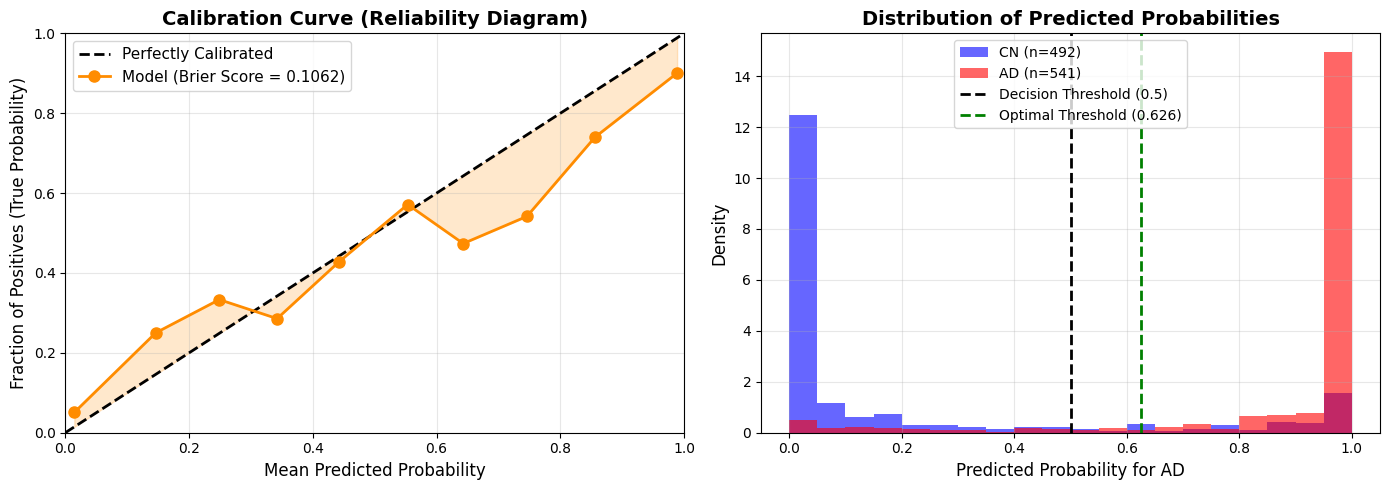


📊 Calibration Metrics:
   Brier Score: 0.1062 (0 = perfect, 0.25 = random)
   Expected Calibration Error (ECE): 0.0736

   Calibration Quality: Good

💡 Interpretation:
   - Brier Score measures the mean squared error between predicted
     probabilities and actual outcomes (lower = better)
   - A well-calibrated model's curve should follow the diagonal
   - Curves above diagonal: model underestimates probability
   - Curves below diagonal: model overestimates probability


In [26]:
# Calibration Analysis
print("\n📐 CALIBRATION ANALYSIS")
print("-" * 50)

from sklearn.metrics import brier_score_loss

# Calculate calibration curve
n_bins = 10
prob_true, prob_pred = calibration_curve(y_true_binary, y_scores, n_bins=n_bins, strategy='uniform')

# Calculate Brier Score (lower is better)
brier_score = brier_score_loss(y_true_binary, y_scores)

# Expected Calibration Error (ECE)
bin_counts = np.histogram(y_scores, bins=n_bins, range=(0, 1))[0]
ece = np.sum(np.abs(prob_true - prob_pred) * bin_counts[:len(prob_true)]) / np.sum(bin_counts[:len(prob_true)]) if len(prob_true) > 0 else 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Calibration Curve (Reliability Diagram)
axes[0].plot([0, 1], [0, 1], 'k--', lw=2, label='Perfectly Calibrated')
axes[0].plot(prob_pred, prob_true, 'o-', color='darkorange', lw=2, markersize=8,
             label=f'Model (Brier Score = {brier_score:.4f})')
axes[0].fill_between(prob_pred, prob_true, prob_pred, alpha=0.2, color='darkorange')
axes[0].set_xlabel('Mean Predicted Probability', fontsize=12)
axes[0].set_ylabel('Fraction of Positives (True Probability)', fontsize=12)
axes[0].set_title('Calibration Curve (Reliability Diagram)', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# Plot 2: Prediction Distribution with Calibration Info
axes[1].hist(y_scores[y_true_binary == 0], bins=20, alpha=0.6, color='blue',
             label=f'CN (n={np.sum(y_true_binary == 0)})', density=True)
axes[1].hist(y_scores[y_true_binary == 1], bins=20, alpha=0.6, color='red',
             label=f'AD (n={np.sum(y_true_binary == 1)})', density=True)
axes[1].axvline(x=0.5, color='black', linestyle='--', lw=2, label='Decision Threshold (0.5)')
axes[1].axvline(x=optimal_threshold, color='green', linestyle='--', lw=2,
                label=f'Optimal Threshold ({optimal_threshold:.3f})')
axes[1].set_xlabel('Predicted Probability for AD', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Distribution of Predicted Probabilities', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper center', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Calibration Metrics:")
print(f"   Brier Score: {brier_score:.4f} (0 = perfect, 0.25 = random)")
print(f"   Expected Calibration Error (ECE): {ece:.4f}")

# Interpretation
if brier_score < 0.1:
    calibration_quality = "Excellent"
elif brier_score < 0.2:
    calibration_quality = "Good"
elif brier_score < 0.25:
    calibration_quality = "Fair"
else:
    calibration_quality = "Poor"

print(f"\n   Calibration Quality: {calibration_quality}")
print(f"\n💡 Interpretation:")
print(f"   - Brier Score measures the mean squared error between predicted")
print(f"     probabilities and actual outcomes (lower = better)")
print(f"   - A well-calibrated model's curve should follow the diagonal")
print(f"   - Curves above diagonal: model underestimates probability")
print(f"   - Curves below diagonal: model overestimates probability")

Combined ROC and PR curve with summary


📊 COMPREHENSIVE EVALUATION SUMMARY


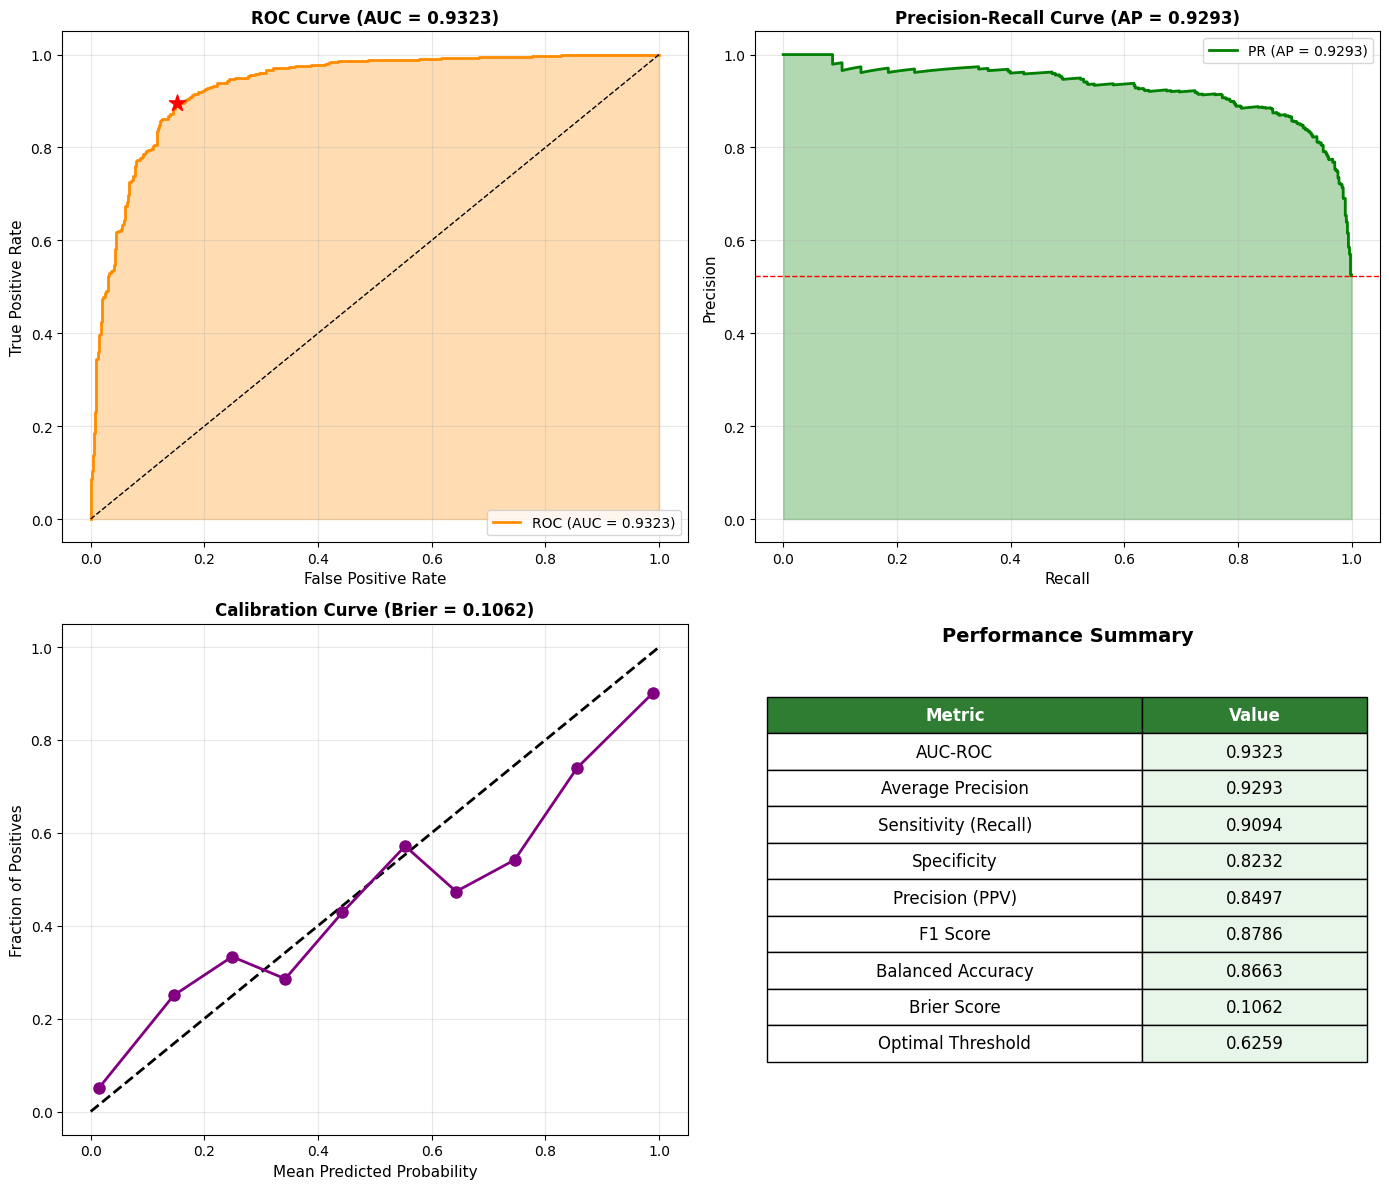


✅ Evaluation Summary:
   • AUC-ROC: 0.9323 - Excellent
   • Average Precision: 0.9293
   • Sensitivity: 0.9094 (ability to detect AD)
   • Specificity: 0.8232 (ability to identify CN)
   • Calibration: Good

💾 Summary plot saved to: model_evaluation_summary.png


In [27]:
# Combined Summary Plot
print("\n📊 COMPREHENSIVE EVALUATION SUMMARY")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: ROC Curve
axes[0, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 0].fill_between(fpr, tpr, alpha=0.3, color='darkorange')
axes[0, 0].scatter(fpr[optimal_idx], tpr[optimal_idx], marker='*', color='red', s=150, zorder=5)
axes[0, 0].set_xlabel('False Positive Rate', fontsize=11)
axes[0, 0].set_ylabel('True Positive Rate', fontsize=11)
axes[0, 0].set_title(f'ROC Curve (AUC = {roc_auc:.4f})', fontsize=12, fontweight='bold')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: PR Curve
axes[0, 1].plot(recall, precision, color='green', lw=2, label=f'PR (AP = {avg_precision:.4f})')
axes[0, 1].axhline(y=baseline, color='red', linestyle='--', lw=1)
axes[0, 1].fill_between(recall, precision, alpha=0.3, color='green')
axes[0, 1].set_xlabel('Recall', fontsize=11)
axes[0, 1].set_ylabel('Precision', fontsize=11)
axes[0, 1].set_title(f'Precision-Recall Curve (AP = {avg_precision:.4f})', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc='upper right')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Calibration Curve
axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=2)
axes[1, 0].plot(prob_pred, prob_true, 'o-', color='purple', lw=2, markersize=8)
axes[1, 0].set_xlabel('Mean Predicted Probability', fontsize=11)
axes[1, 0].set_ylabel('Fraction of Positives', fontsize=11)
axes[1, 0].set_title(f'Calibration Curve (Brier = {brier_score:.4f})', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Summary Metrics Table
axes[1, 1].axis('off')
summary_data = [
    ['Metric', 'Value'],
    ['AUC-ROC', f'{roc_auc:.4f}'],
    ['Average Precision', f'{avg_precision:.4f}'],
    ['Sensitivity (Recall)', f'{sensitivity:.4f}'],
    ['Specificity', f'{specificity:.4f}'],
    ['Precision (PPV)', f'{ppv:.4f}'],
    ['F1 Score', f'{f1:.4f}'],
    ['Balanced Accuracy', f'{balanced_acc:.4f}'],
    ['Brier Score', f'{brier_score:.4f}'],
    ['Optimal Threshold', f'{optimal_threshold:.4f}']
]

table = axes[1, 1].table(cellText=summary_data[1:], colLabels=summary_data[0],
                          loc='center', cellLoc='center',
                          colColours=['#4CAF50', '#4CAF50'],
                          colWidths=[0.5, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8)

# Style header
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight='bold', color='white')
        cell.set_facecolor('#2E7D32')
    else:
        if col == 1:
            cell.set_facecolor('#E8F5E9')

axes[1, 1].set_title('Performance Summary', fontsize=14, fontweight='bold', y=0.95)

plt.tight_layout()
plt.savefig('model_evaluation_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Evaluation Summary:")
print(f"   • AUC-ROC: {roc_auc:.4f} - {'Excellent' if roc_auc > 0.9 else 'Good' if roc_auc > 0.8 else 'Fair' if roc_auc > 0.7 else 'Poor'}")
print(f"   • Average Precision: {avg_precision:.4f}")
print(f"   • Sensitivity: {sensitivity:.4f} (ability to detect AD)")
print(f"   • Specificity: {specificity:.4f} (ability to identify CN)")
print(f"   • Calibration: {calibration_quality}")
print(f"\n💾 Summary plot saved to: model_evaluation_summary.png")

## 8. Visualize Training History


8️⃣  TRAINING HISTORY
--------------------------------------------------------------------------------


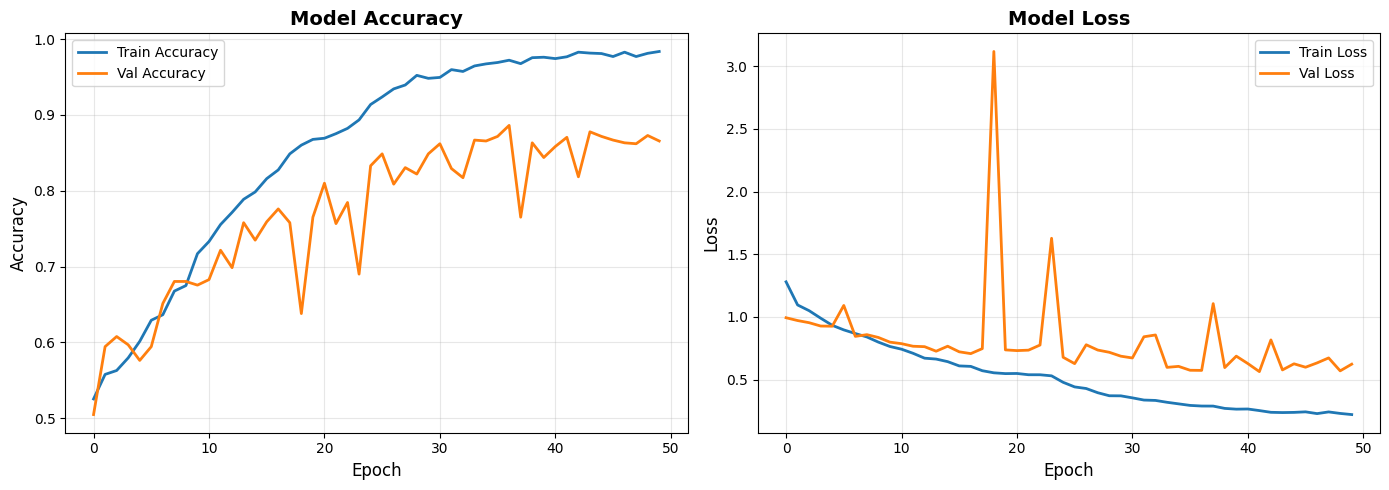

In [28]:
print("\n8️⃣  TRAINING HISTORY")
print("-" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Load and Predict on Test-Dist Data

In [30]:
print("\n9️⃣  PREDICTIONS ON TEST-DIST DATA (WITH PAR SEGMENTATION)")
print("=" * 80)

def load_test_segmented_audio(audio_folder, seg_folder, sr=16000, speaker='PAR', min_duration=1.0):
    """
    Load test audio files using PAR segmentation for consistency with training.
    Returns segments grouped by file ID for aggregated predictions.
    """
    all_segments = []  # (segment, file_id)
    file_ids_unique = []

    audio_files = sorted([f for f in os.listdir(audio_folder) if f.endswith('.wav')])

    for filename in audio_files:
        audio_path = os.path.join(audio_folder, filename)
        file_id = os.path.splitext(filename)[0]

        # Find matching segmentation file (adrsdt*.csv format)
        seg_filename = file_id + '.csv'
        seg_path = os.path.join(seg_folder, seg_filename)

        if os.path.exists(seg_path):
            try:
                seg_df = pd.read_csv(seg_path)
                y_full, _ = librosa.load(audio_path, sr=sr)

                # Extract PAR segments
                par_segments = seg_df[seg_df['speaker'] == speaker]

                for _, row in par_segments.iterrows():
                    begin_sample = int(row['begin'] * sr / 1000)
                    end_sample = int(row['end'] * sr / 1000)
                    segment = y_full[begin_sample:end_sample]

                    if len(segment) > sr * min_duration:
                        segment = librosa.util.normalize(segment)
                        all_segments.append((segment, file_id))

                if file_id not in file_ids_unique:
                    file_ids_unique.append(file_id)

            except Exception as e:
                print(f"  Error processing {filename}: {e}")
        else:
            # No segmentation file - load full audio
            try:
                y, _ = librosa.load(audio_path, sr=sr)
                y = librosa.util.normalize(y)
                all_segments.append((y, file_id))
                if file_id not in file_ids_unique:
                    file_ids_unique.append(file_id)
            except Exception as e:
                print(f"  Error loading {filename}: {e}")

    return all_segments, file_ids_unique

# Load test audio with segmentation
test_segments, test_ids = load_test_segmented_audio(
    CONFIG['test_folder'],
    CONFIG['test_seg_folder'],
    CONFIG['sr'],
    min_duration=CONFIG['min_segment_duration']
)

print(f"Loaded {len(test_segments)} PAR segments from {len(test_ids)} test files")

# Standardize segment lengths
test_audio_standardized = [
    standardize_segment_length(seg, TARGET_LENGTH)
    for seg, _ in test_segments
]

# Extract spectrograms
test_spectrograms = [
    audio_to_melspectrogram(audio, CONFIG['sr'], CONFIG['n_mels'], CONFIG['fmax'])
    for audio in test_audio_standardized
]

X_test_dist = np.array(test_spectrograms)[..., np.newaxis]
print(f"Test data shape: {X_test_dist.shape}")

# Make predictions
y_pred_proba = model.predict(X_test_dist, verbose=0)
y_pred_segments = np.argmax(y_pred_proba, axis=1)

# Aggregate predictions by file (majority voting with confidence)
print("\nAggregating segment predictions per file...")
file_predictions = {}
file_confidences = {}

for i, (_, file_id) in enumerate(test_segments):
    if file_id not in file_predictions:
        file_predictions[file_id] = []
        file_confidences[file_id] = []
    file_predictions[file_id].append(y_pred_segments[i])
    file_confidences[file_id].append(y_pred_proba[i])

# Final prediction per file using majority voting
final_predictions = {}
final_confidences = {}

for file_id in test_ids:
    preds = file_predictions[file_id]
    confs = file_confidences[file_id]

    # Majority vote
    pred_counts_file = Counter(preds)
    final_pred = pred_counts_file.most_common(1)[0][0]
    final_predictions[file_id] = final_pred

    # Average confidence for the winning class
    avg_conf = np.mean([confs[i][final_pred] for i in range(len(preds)) if preds[i] == final_pred])
    final_confidences[file_id] = avg_conf

y_pred_labels = [le.inverse_transform([final_predictions[fid]])[0] for fid in test_ids]

# Show prediction distribution
print("\nPrediction Distribution (per file):")
pred_counts = Counter(y_pred_labels)
for label, count in pred_counts.items():
    print(f"  {label}: {count} files ({count/len(y_pred_labels)*100:.1f}%)")

# Show sample predictions
print("\nSample Predictions (first 10):")
for i in range(min(10, len(test_ids))):
    fid = test_ids[i]
    n_segs = len(file_predictions[fid])
    print(f"  {fid}: {y_pred_labels[i]} (confidence: {final_confidences[fid]:.2%}, {n_segs} segments)")


9️⃣  PREDICTIONS ON TEST-DIST DATA (WITH PAR SEGMENTATION)
Loaded 860 PAR segments from 71 test files
Test data shape: (860, 128, 94, 1)

Aggregating segment predictions per file...


KeyError: 'adrsdt49'

## 10. Save Predictions to CSV

In [ ]:
print("\n🔟 SAVING PREDICTIONS")
print("-" * 80)

# Convert to lowercase (ad/cn format)
predictions_lower = [label.lower() for label in y_pred_labels]

results_df = pd.DataFrame({
    'ID': test_ids,
    'Prediction': predictions_lower
})

# Sort by ID
results_df = results_df.sort_values('ID').reset_index(drop=True)

# Save
output_path = 'test-dist/my_predictions_task1.csv'
results_df.to_csv(output_path, index=False)
print(f"✓ Predictions saved to: {output_path}")

# Display all predictions
print("\nAll Predictions:")
print(results_df.to_string(index=False, max_rows=20))
if len(results_df) > 20:
    print(f"... ({len(results_df) - 20} more rows)")

## 11. Save Model and Preprocessing Parameters

In [ ]:
print("\n1️⃣1️⃣  SAVING MODEL AND PARAMETERS")
print("-" * 80)

# Save model
model.save('alzheimers_cnn_model_improved.keras')
print("✓ Model saved: alzheimers_cnn_model_improved.keras")

# Save label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("✓ Label encoder saved: label_encoder.pkl")

# Save preprocessing parameters
preprocessing_params = {
    'sr': CONFIG['sr'],
    'segment_duration': CONFIG['segment_duration'],
    'n_mels': CONFIG['n_mels'],
    'fmax': CONFIG['fmax'],
    'target_length': TARGET_LENGTH,
    'spectrogram_shape': spectrograms[0].shape
}
with open('preprocessing_params.pkl', 'wb') as f:
    pickle.dump(preprocessing_params, f)
print("✓ Preprocessing params saved: preprocessing_params.pkl")

print("\n" + "=" * 80)
print("✅ PIPELINE COMPLETE!")
print("=" * 80)
print(f"Final Test Accuracy: {test_acc:.2%}")
print(f"Total Training Segments: {len(X_train)}")
print(f"Test Predictions: {len(test_ids)} files")
print("=" * 80)